# Fast Word2Vec negative sampling with PyTorch GPU

This notebook trains a skip-gram with negative sampling (SGNS) model on the Mahabharata. Training pairs and negative words are sampled in large vectorized batches on the GPU. It then explores character relationships with cosine similarity, PCA, and t-SNE.

> Run all cells in order. If CUDA is unavailable the same code falls back to CPU.

In [11]:
from pathlib import Path
from collections import Counter
import random, re, time, urllib.request

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    torch.backends.cuda.matmul.allow_tf32 = True

PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA L4


In [12]:
# Configuration: lower STEPS for a quick test; raise it for better embeddings.
DATASET_URL = 'https://raw.githubusercontent.com/bhagatpandey369/NLP/refs/heads/main/dataset/1-18%20books%20combined.txt'
CORPUS_FILE = Path('mahabharata_corpus.txt')
MIN_COUNT = 5
MAX_VOCAB = 10_000
EMBED_DIM = 200
WINDOW = 5
NEGATIVES = 10
BATCH_SIZE = 16_384 if DEVICE.type == 'cuda' else 2_048
STEPS = 3_000
LEARNING_RATE = 0.003
PRINT_EVERY = 100

if not CORPUS_FILE.exists():
    print('Downloading corpus once...')
    urllib.request.urlretrieve(DATASET_URL, CORPUS_FILE)
text = CORPUS_FILE.read_text(encoding='utf-8', errors='ignore').lower()
print(f'{len(text):,} characters loaded from {CORPUS_FILE.resolve()}')

1,701,795 characters loaded from /content/mahabharata_corpus.txt


In [13]:
# Join common multi-token character names so each becomes one vocabulary item.
ALIASES = {
    'yudhishthira': ['yudhisthira', 'yudhishthir', 'yudhisthir'],
    'duryodhana': ['duryodhan'], 'duhshasana': ['dussasana', 'duhsasana'],
    'dhritarashtra': ['dhritarashtra'], 'gandhari': [], 'kunti': ['pritha'],
    'bhishma': ['bhisma'], 'drona': ['dronacharya'], 'ashwatthama': ['aswatthaman', 'aswatthama'],
    'krishna': ['vasudeva', 'kesava', 'keshava'], 'arjuna': ['arjun', 'partha', 'dhananjaya'],
    'bhima': ['bheema', 'bhimasena'], 'karna': ['radheya'], 'draupadi': ['krishnaa'],
    'nakula': ['nakul'], 'sahadeva': ['sahadev'], 'shakuni': ['sakuni'],
    'abhimanyu': ['abhimanyyu'], 'subhadra': [], 'vidura': ['vidur']
}
for canonical, variants in ALIASES.items():
    for variant in variants:
        text = re.sub(rf'\b{re.escape(variant)}\b', canonical, text)
tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", text)
counts = Counter(tokens)
vocab = [w for w, c in counts.most_common(MAX_VOCAB) if c >= MIN_COUNT]
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = np.asarray(vocab)
ids = np.fromiter((word_to_id[w] for w in tokens if w in word_to_id), dtype=np.int64)
corpus_ids = torch.from_numpy(ids)  # kept in pinned CPU memory when possible
if DEVICE.type == 'cuda': corpus_ids = corpus_ids.pin_memory()
freq = torch.tensor([counts[w] for w in vocab], dtype=torch.float32, device=DEVICE)
negative_probs = freq.pow(0.75); negative_probs /= negative_probs.sum()
print(f'Tokens: {len(tokens):,} | retained: {len(ids):,} | vocabulary: {len(vocab):,}')
print('Characters present:', [x for x in ALIASES if x in word_to_id])

Tokens: 291,327 | retained: 279,677 | vocabulary: 3,907
Characters present: ['yudhishthira', 'duryodhana', 'duhshasana', 'gandhari', 'kunti', 'bhishma', 'drona', 'krishna', 'arjuna', 'bhima', 'karna', 'draupadi', 'nakula', 'sahadeva', 'shakuni', 'abhimanyu', 'subhadra', 'vidura']


In [14]:
class SGNS(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        self.target = nn.Embedding(vocab_size, dim)
        self.context = nn.Embedding(vocab_size, dim)
        bound = 0.5 / dim
        nn.init.uniform_(self.target.weight, -bound, bound)
        nn.init.zeros_(self.context.weight)

    def forward(self, target_ids, context_ids, negative_ids):
        target = self.target(target_ids)
        positive = self.context(context_ids)
        negative = self.context(negative_ids)
        positive_score = (target * positive).sum(1)
        negative_score = torch.bmm(negative, target.unsqueeze(2)).squeeze(2)
        return -(F.logsigmoid(positive_score) + F.logsigmoid(-negative_score).sum(1)).mean()

model = SGNS(len(vocab), EMBED_DIM).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0)
print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

Model parameters: 1,562,800


In [15]:
# Vectorized GPU training. Each row samples a real center word, a random nearby
# context position, and NEGATIVES noise words from the unigram^0.75 distribution.
model.train(); running = 0.0; started = time.perf_counter()
low, high = WINDOW, len(corpus_ids) - WINDOW
for step in range(1, STEPS + 1):
    positions = torch.randint(low, high, (BATCH_SIZE,))
    offsets = torch.randint(0, 2 * WINDOW, (BATCH_SIZE,)) - WINDOW
    offsets += (offsets >= 0).long()  # -WINDOW..-1 or 1..WINDOW; never zero
    target_ids = corpus_ids[positions].to(DEVICE, non_blocking=True)
    context_ids = corpus_ids[positions + offsets].to(DEVICE, non_blocking=True)
    negative_ids = torch.multinomial(negative_probs, BATCH_SIZE * NEGATIVES, replacement=True).view(BATCH_SIZE, NEGATIVES)
    optimizer.zero_grad(set_to_none=True)
    loss = model(target_ids, context_ids, negative_ids)
    loss.backward(); optimizer.step()
    running += loss.item()
    if step % PRINT_EVERY == 0:
        elapsed = time.perf_counter() - started
        rate = step * BATCH_SIZE / elapsed
        print(f'step {step:>5}/{STEPS} | loss {running/PRINT_EVERY:.4f} | {rate:,.0f} pairs/s')
        running = 0.0
print(f'Finished in {(time.perf_counter()-started)/60:.1f} minutes')

step   100/3000 | loss 4.1597 | 3,004,320 pairs/s
step   200/3000 | loss 3.2160 | 2,991,946 pairs/s
step   300/3000 | loss 3.2150 | 2,996,062 pairs/s
step   400/3000 | loss 3.1969 | 2,999,441 pairs/s
step   500/3000 | loss 3.1542 | 3,003,241 pairs/s
step   600/3000 | loss 3.1231 | 3,002,785 pairs/s
step   700/3000 | loss 3.0931 | 3,003,380 pairs/s
step   800/3000 | loss 3.0651 | 3,002,242 pairs/s
step   900/3000 | loss 3.0385 | 3,003,189 pairs/s
step  1000/3000 | loss 3.0149 | 3,000,168 pairs/s
step  1100/3000 | loss 2.9937 | 3,000,883 pairs/s
step  1200/3000 | loss 2.9742 | 3,001,695 pairs/s
step  1300/3000 | loss 2.9552 | 3,002,076 pairs/s
step  1400/3000 | loss 2.9376 | 3,002,674 pairs/s
step  1500/3000 | loss 2.9237 | 2,998,054 pairs/s
step  1600/3000 | loss 2.9081 | 2,995,224 pairs/s
step  1700/3000 | loss 2.8960 | 2,991,355 pairs/s
step  1800/3000 | loss 2.8824 | 2,991,980 pairs/s
step  1900/3000 | loss 2.8719 | 2,992,416 pairs/s
step  2000/3000 | loss 2.8612 | 2,992,283 pairs/s


In [16]:
# Normalize once for fast cosine-similarity searches.
model.eval()
with torch.no_grad():
    embeddings = F.normalize(model.target.weight + model.context.weight, dim=1).cpu()

def most_similar(word, top_k=10, restrict_to=None):
    word = word.lower()
    if word not in word_to_id:
        print(f'{word!r} is not in the vocabulary'); return []
    candidates = [w for w in (restrict_to or vocab) if w in word_to_id and w != word]
    candidate_ids = torch.tensor([word_to_id[w] for w in candidates])
    scores = embeddings[candidate_ids] @ embeddings[word_to_id[word]]
    k = min(top_k, len(candidates))
    values, order = torch.topk(scores, k)
    result = [(candidates[i], float(s)) for i, s in zip(order.tolist(), values)]
    for name, score in result: print(f'{name:18s} {score:.4f}')
    return result

CHARACTERS = [w for w in ALIASES if w in word_to_id]
print('Characters closest to Arjuna:')
_ = most_similar('arjuna', top_k=10, restrict_to=CHARACTERS)

Characters closest to Arjuna:
subhadra           0.3206
krishna            0.2762
nakula             0.2064
bhima              0.1886
sahadeva           0.1854
karna              0.1750
bhishma            0.1442
drona              0.1149
kunti              0.1125
yudhishthira       0.0949


In [17]:
# Character-to-character cosine-similarity table.
import pandas as pd
char_ids = torch.tensor([word_to_id[w] for w in CHARACTERS])
char_similarity = (embeddings[char_ids] @ embeddings[char_ids].T).numpy()
pd.DataFrame(char_similarity, index=CHARACTERS, columns=CHARACTERS).round(2)

,yudhishthira,duryodhana,duhshasana,gandhari,kunti,bhishma,drona,krishna,arjuna,bhima,karna,draupadi,nakula,sahadeva,shakuni,abhimanyu,subhadra,vidura
yudhishthira,1.00,0.12,-0.01,0.17,0.11,0.04,0.08,0.08,0.09,0.21,0.04,0.23,0.41,0.35,0.08,-0.12,-0.03,0.21
duryodhana,0.12,1.00,0.46,0.15,-0.11,0.13,0.27,-0.04,0.02,0.17,0.34,0.05,0.09,0.00,0.37,0.16,-0.05,0.26
duhshasana,-0.01,0.46,1.00,0.18,-0.11,0.06,0.18,-0.12,-0.02,0.21,0.39,0.24,0.15,0.10,0.51,0.23,-0.04,0.13
gandhari,0.17,0.15,0.18,1.00,0.30,0.17,0.00,0.04,-0.15,0.05,-0.08,0.12,0.04,-0.00,0.04,-0.05,0.13,0.36
kunti,0.11,-0.11,-0.11,0.30,1.00,-0.02,-0.06,-0.01,0.11,0.21,-0.00,0.20,0.15,0.15,-0.06,-0.03,0.19,0.13
bhishma,0.04,0.13,0.06,0.17,-0.02,1.00,0.48,0.10,0.14,-0.09,0.26,-0.06,-0.05,-0.00,0.10,0.07,-0.08,0.20
drona,0.08,0.27,0.18,0.00,-0.06,0.48,1.00,-0.15,0.11,0.04,0.33,-0.06,-0.04,-0.07,0.09,0.17,-0.14,0.18
krishna,0.08,-0.04,-0.12,0.04,-0.01,0.10,-0.15,1.00,0.28,-0.03,-0.03,0.03,0.05,0.06,-0.12,-0.16,0.18,0.05
arjuna,0.09,0.02,-0.02,-0.15,0.11,0.14,0.11,0.28,1.00,0.19,0.18,0.09,0.21,0.19,-0.03,0.07,0.32,-0.18
bhima,0.21,0.17,0.21,0.05,0.21,-0.09,0.04,-0.03,0.19,1.00,0.20,0.23,0.37,0.36,0.06,0.09,-0.05,0.01


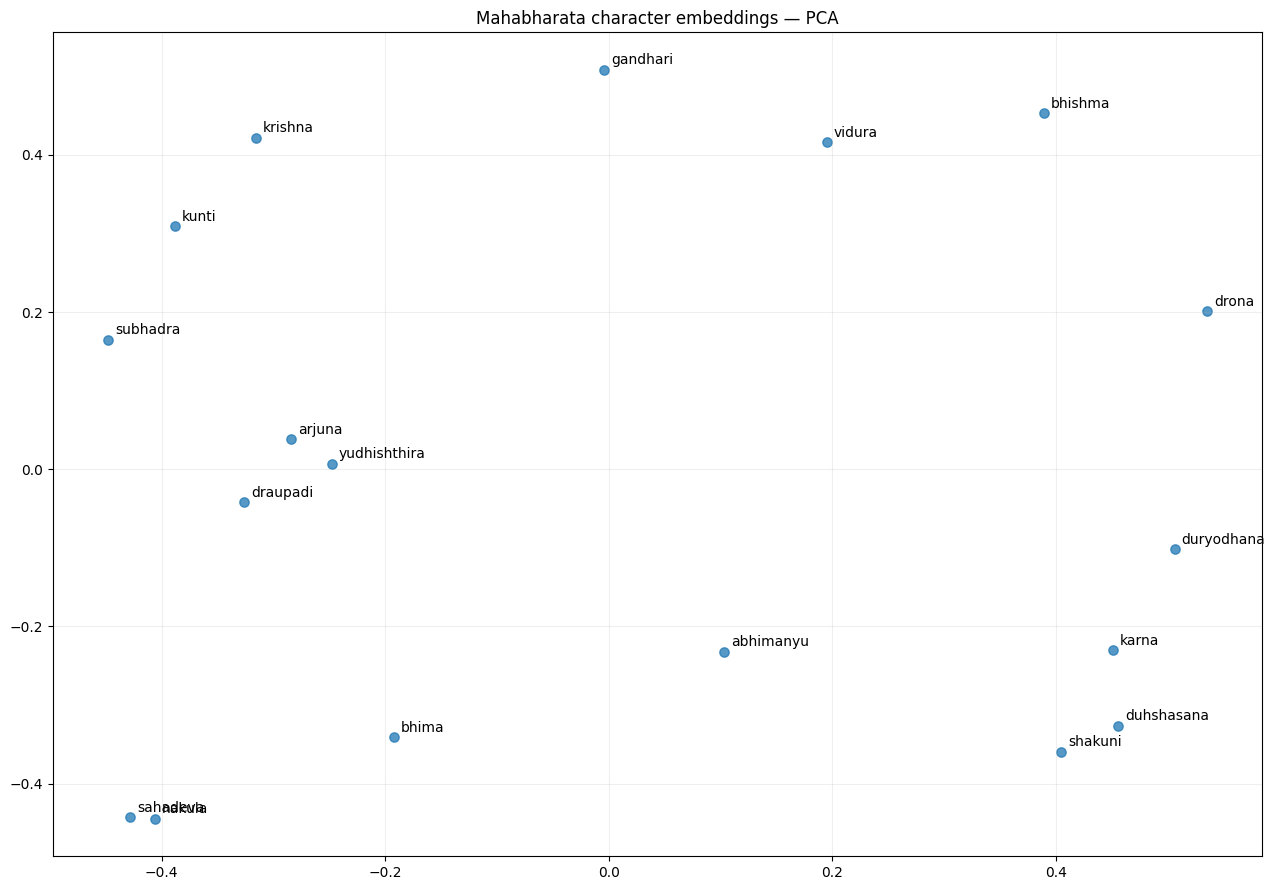

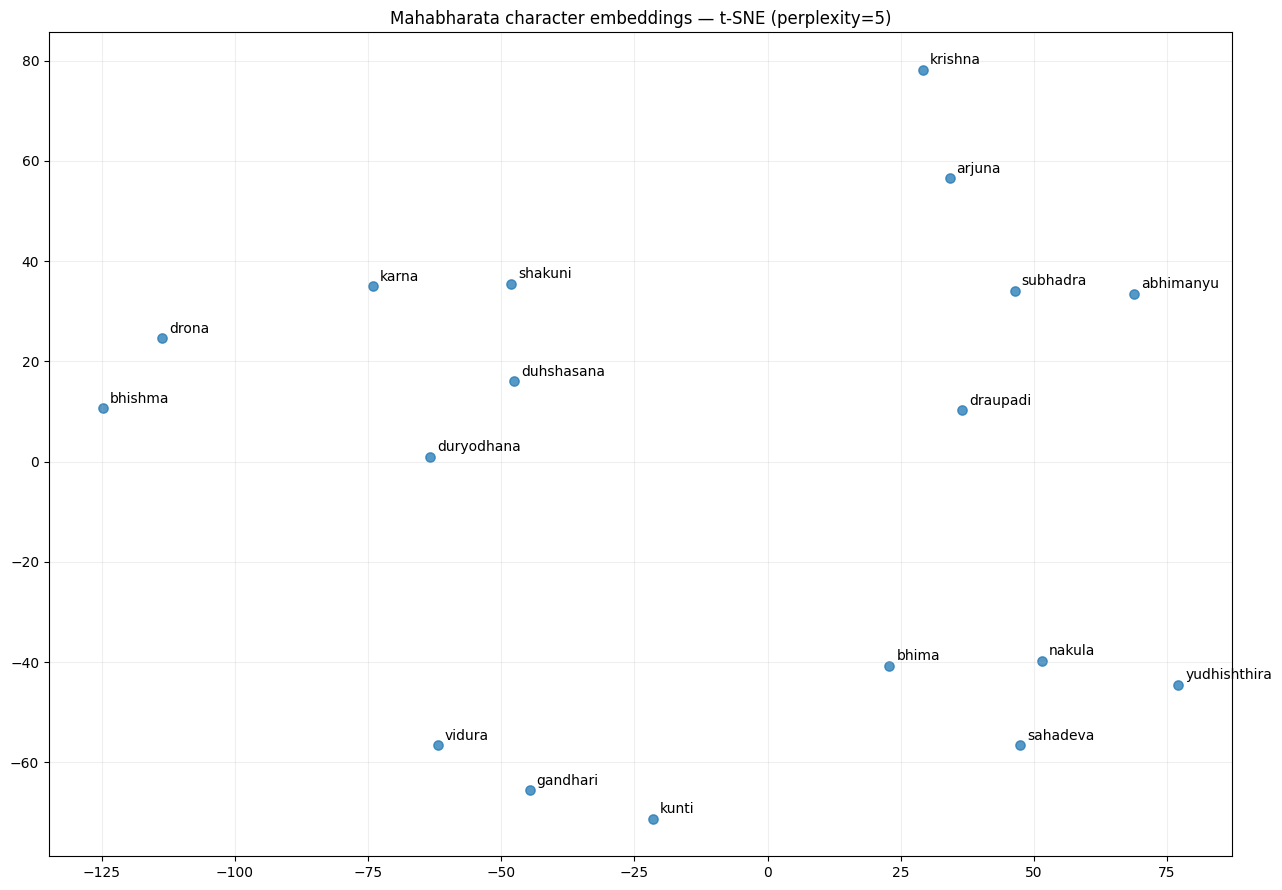

In [19]:
# PCA plot (deterministic and usually easiest to interpret).
from sklearn.decomposition import PCA

def plot_words(words, method='pca'):
    words = list(dict.fromkeys(w.lower() for w in words if w.lower() in word_to_id))
    matrix = embeddings[[word_to_id[w] for w in words]].numpy()
    if method.lower() == 'tsne':
        from sklearn.manifold import TSNE
        perplexity = min(10, max(2, (len(words) - 1) // 3))
        points = TSNE(n_components=2, perplexity=perplexity, init='pca', learning_rate='auto', random_state=SEED).fit_transform(matrix)
        title = f'Mahabharata character embeddings — t-SNE (perplexity={perplexity})'
    else:
        points = PCA(n_components=2).fit_transform(matrix)
        title = 'Mahabharata character embeddings — PCA'
    plt.figure(figsize=(13, 9)); plt.scatter(points[:, 0], points[:, 1], s=45, alpha=.75)
    for (x, y), word in zip(points, words): plt.annotate(word, (x, y), xytext=(5, 4), textcoords='offset points', fontsize=10)
    plt.title(title); plt.grid(alpha=.2); plt.tight_layout(); plt.show()

plot_words(CHARACTERS, method='pca')
# Try the nonlinear view too:
plot_words(CHARACTERS, method='tsne')

In [20]:
# Save everything required to reuse the trained model.
OUTPUT_FILE = Path('mahabharata_sgns_gpu.pt')
torch.save({'state_dict': model.state_dict(), 'vocab': vocab, 'config': {
    'embedding_dim': EMBED_DIM, 'window': WINDOW, 'negative_samples': NEGATIVES,
    'min_count': MIN_COUNT, 'steps': STEPS}}, OUTPUT_FILE)
print('Saved:', OUTPUT_FILE.resolve())

Saved: /content/mahabharata_sgns_gpu.pt
